In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

In [26]:
df = pd.read_csv("https://raw.githubusercontent.com/kzming2007/Catholic_ML_final_project/refs/heads/main/dataset/ur3_cobotops.csv")

# REGRESSION
## current,speed 데이터를 기반으로 tool current를 예측

## linear regression

In [27]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# 1. 결측치 없는 클린 데이터 로드 및 분리
df_clean = df.dropna().copy()

# 입력 피처(X): 12개 조인트 피처
input_cols = [
    'Current_J0', 'Current_J1', 'Current_J2', 'Current_J3', 'Current_J4', 'Current_J5',
    'Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5'
]
X = df_clean[input_cols]

# 타겟(y): 그리퍼 전류
y = df_clean['Tool_current']

# 2. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 비교할 스케일러 정의
scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler()
}

print("--- [최적 피벗] 그리퍼 전류(Tool_current) 스케일러별 회귀 결과 ---")

# 4. 루프를 돌며 스케일러별 학습 및 평가
for name, scaler in scalers.items():
    # 데이터 스케일링
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 4. 다항 피처 변환 (Degree=2)
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)

    # 모델 학습 및 예측
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    y_pred = model.predict(X_test_poly)

    # 결과 출력
    print(f"\n[{name} 결과]")
    print(f"R² (결정계수): {r2_score(y_test, y_pred):.4f}")
    print(f"MSE (평균제곱오차): {mean_squared_error(y_test, y_pred):.6f}")

--- [최적 피벗] 그리퍼 전류(Tool_current) 스케일러별 회귀 결과 ---

[StandardScaler 결과]
R² (결정계수): 0.2340
MSE (평균제곱오차): 0.004207

[MinMaxScaler 결과]
R² (결정계수): 0.2340
MSE (평균제곱오차): 0.004207


In [28]:
# Ridge, Lasso, ElasticNet 모델 스케일러별 비교
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error

# 1. 스케일러 및 모델 정의
scalers = {
    "Standard": StandardScaler(),
    "MinMax": MinMaxScaler()
}

models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=1.0),
    "ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5)
}

# 결과를 저장할 리스트
results = []

# 2. 루프 실행 (스케일러 x 모델 조합)
for s_name, scaler in scalers.items():
    # 현재 스케일러로 데이터 변환
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

        # 4. 다항 피처 변환 (Degree=2) - 최적의 성능을 낸 비결!
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)

    for m_name, model in models.items():
        # 모델 학습 및 예측
        model.fit(X_train_poly, y_train)
        y_pred = model.predict(X_test_poly)

        # 평가지표 계산
        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)

        # 결과 저장
        results.append({
            "Scaler": s_name,
            "Model": m_name,
            "R2": round(r2, 4),
            "MSE": round(mse, 6)
        })

# 3. 데이터프레임 변환 및 출력
df_res = pd.DataFrame(results)
print("--- [최적 피벗] 선형 규제 모델 성능 비교 결과 ---")
display(df_res.sort_values(by="R2", ascending=False)) # R2 기준 내림차순 정렬


--- [최적 피벗] 선형 규제 모델 성능 비교 결과 ---


,Scaler,Model,R2,MSE
0,Standard,Ridge,0.2340,0.004207
3,MinMax,Ridge,0.1760,0.004525
1,Standard,Lasso,-0.0023,0.005504
2,Standard,ElasticNet,-0.0023,0.005504
4,MinMax,Lasso,-0.0023,0.005504
5,MinMax,ElasticNet,-0.0023,0.005504


## RandomForestRegressor

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import time

df.columns = df.columns.str.strip()

# 피처 및 타겟 정의
input_cols = [f"Current_J{i}" for i in range(6)] + [f"Speed_J{i}" for i in range(6)]
target_col = "Tool_current"

# 결측치 제거
clean_df = df.dropna(subset=input_cols + [target_col])
X = clean_df[input_cols]
y = clean_df[target_col]

# 5-Fold Cross Validation 설정
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 랜덤 포레스트 모델 정의 (빠른 실행을 위해 n_estimators=100, max_depth=15, n_jobs=-1 로 멀티코어 사용)
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)

r2_scores = []
mae_scores = []
rmse_scores = []

print("Evaluating RandomForestRegressor with 5-Fold CV (Multi-core)...")
start_time = time.time()

fold = 1
for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
    y_train, y_test = y.iloc[train_idx].values, y.iloc[test_idx].values

    # 랜덤포레스트는 원래 스케일링이 필요 없지만 일관성을 위해 유지하거나 생략 가능. 여기서는 피처 원본 그대로 사용
    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    r2_scores.append(r2)
    mae_scores.append(mae)
    rmse_scores.append(rmse)

    print(f"  Fold {fold} - R2: {r2:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}")
    fold += 1

elapsed = time.time() - start_time
print(f"\nEvaluation finished in {elapsed:.4f} seconds.")
print(f"--- RandomForestRegressor Mean Metrics ---")
print(f"  Mean R^2 : {np.mean(r2_scores):.4f}")
print(f"  Mean MAE : {np.mean(mae_scores):.4f} A")
print(f"  Mean RMSE: {np.mean(rmse_scores):.4f} A")

Evaluating RandomForestRegressor with 5-Fold CV (Multi-core)...
  Fold 1 - R2: 0.5266, MAE: 0.0191, RMSE: 0.0510
  Fold 2 - R2: 0.5933, MAE: 0.0185, RMSE: 0.0493
  Fold 3 - R2: 0.6137, MAE: 0.0189, RMSE: 0.0511
  Fold 4 - R2: 0.5737, MAE: 0.0193, RMSE: 0.0523
  Fold 5 - R2: 0.5501, MAE: 0.0198, RMSE: 0.0537

Evaluation finished in 53.2275 seconds.
--- RandomForestRegressor Mean Metrics ---
  Mean R^2 : 0.5715
  Mean MAE : 0.0191 A
  Mean RMSE: 0.0515 A


--- [Random Forest 평가 루프 시작] ---
RF (depth=1 ) -> Train R2: 0.0749 | Test R2: 0.0575 | Gap: 0.0173
RF (depth=2 ) -> Train R2: 0.1841 | Test R2: 0.1619 | Gap: 0.0222
RF (depth=3 ) -> Train R2: 0.3283 | Test R2: 0.2917 | Gap: 0.0366
RF (depth=4 ) -> Train R2: 0.4435 | Test R2: 0.3787 | Gap: 0.0648
RF (depth=5 ) -> Train R2: 0.5333 | Test R2: 0.4305 | Gap: 0.1027
RF (depth=6 ) -> Train R2: 0.6157 | Test R2: 0.4693 | Gap: 0.1464
RF (depth=7 ) -> Train R2: 0.6935 | Test R2: 0.5019 | Gap: 0.1916
RF (depth=8 ) -> Train R2: 0.7610 | Test R2: 0.5280 | Gap: 0.2330
RF (depth=9 ) -> Train R2: 0.8154 | Test R2: 0.5445 | Gap: 0.2708
RF (depth=10) -> Train R2: 0.8553 | Test R2: 0.5534 | Gap: 0.3020
RF (depth=11) -> Train R2: 0.8832 | Test R2: 0.5608 | Gap: 0.3223
RF (depth=12) -> Train R2: 0.9025 | Test R2: 0.5625 | Gap: 0.3400
RF (depth=13) -> Train R2: 0.9153 | Test R2: 0.5636 | Gap: 0.3517
RF (depth=14) -> Train R2: 0.9241 | Test R2: 0.5651 | Gap: 0.3590
RF (depth=15) -> Train R2: 0.9294 | Test R2

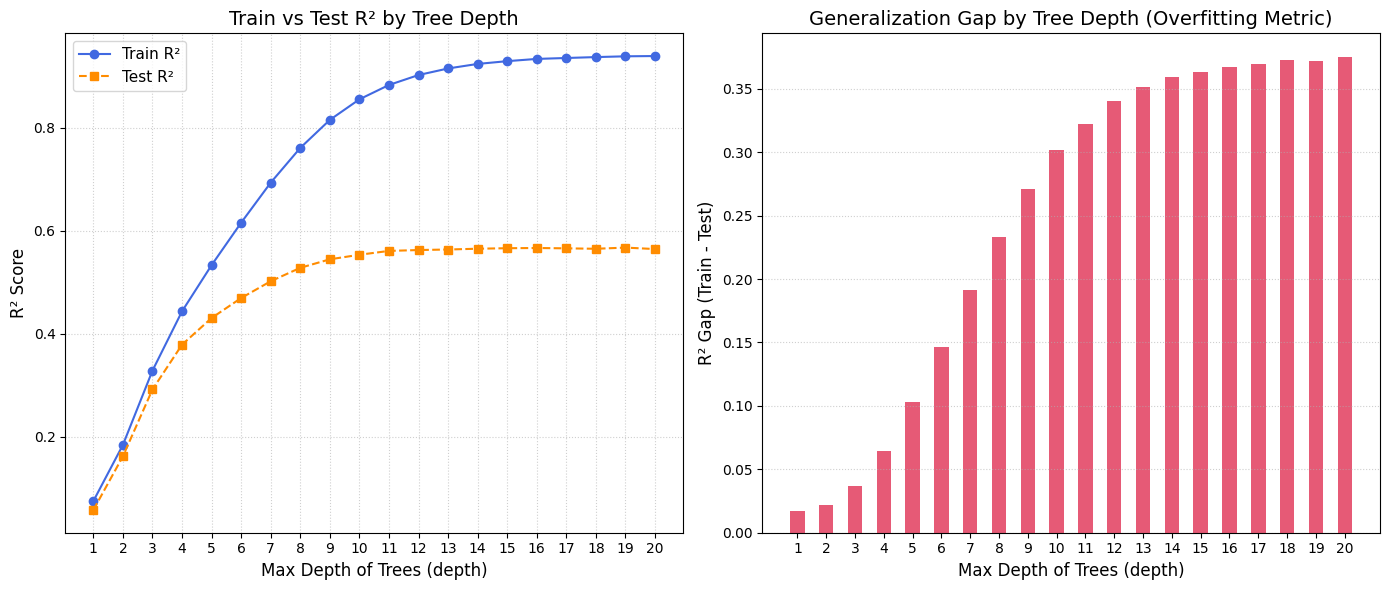

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor  # 랜덤 포레스트 임포트
from sklearn.metrics import r2_score

# 1. 피처 및 타겟 지정 (데이터프레임 df가 사전에 정의되어 있다고 가정합니다)
df.columns = df.columns.str.strip()
input_cols = [f"Current_J{i}" for i in range(6)] + [f"Speed_J{i}" for i in range(6)]
target_col = "Tool_current"

clean_df = df.dropna(subset=input_cols + [target_col])
X = clean_df[input_cols]
y = clean_df[target_col]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 시각화를 위해 탐색할 트리 깊이(max_depth) 정의 (1부터 20까지)
depth_values = list(range(1, 20 + 1))
train_results = []
test_results = []
gap_results = []

print("--- [Random Forest 평가 루프 시작] ---")
for depth in depth_values:
    # n_estimators(트리 개수)는 50으로 설정하여 속도와 성능의 균형을 맞췄습니다. (필요 시 100으로 변경 가능)
    rf = RandomForestRegressor(n_estimators=50, max_depth=depth, random_state=42, n_jobs=-1)
    train_r2s = []
    test_r2s = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx].values, y.iloc[test_idx].values

        # [참고] 랜덤 포레스트는 스케일러와 다항 변환(Polynomial) 없이도
        # 비선형 관계를 스스로 학습하므로 원본 데이터를 바로 사용합니다.
        rf.fit(X_train, y_train)

        # R2 스코어 기록
        train_r2s.append(r2_score(y_train, rf.predict(X_train)))
        test_r2s.append(r2_score(y_test, rf.predict(X_test)))

    mean_train = np.mean(train_r2s)
    mean_test = np.mean(test_r2s)
    mean_gap = mean_train - mean_test

    # 결과를 리스트에 저장
    train_results.append(mean_train)
    test_results.append(mean_test)
    gap_results.append(mean_gap)

    print(f"RF (depth={depth:<2}) -> Train R2: {mean_train:.4f} | Test R2: {mean_test:.4f} | Gap: {mean_gap:.4f}")


# 2. 시각화 (Matplotlib 활용)
plt.figure(figsize=(14, 6))

# 첫 번째 그래프: Depth 변화에 따른 Train vs Test R2 성능 비교
plt.subplot(1, 2, 1)
plt.plot(depth_values, train_results, marker='o', linestyle='-', color='royalblue', label='Train R²')
plt.plot(depth_values, test_results, marker='s', linestyle='--', color='darkorange', label='Test R²')
plt.xlabel('Max Depth of Trees (depth)', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Train vs Test R² by Tree Depth', fontsize=14)
plt.xticks(depth_values)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

# 두 번째 그래프: Depth 변화에 따른 일반화 격차 (Train R2 - Test R2) 비교
plt.subplot(1, 2, 2)
plt.bar([str(d) for d in depth_values], gap_results, color='crimson', alpha=0.7, width=0.5)
plt.xlabel('Max Depth of Trees (depth)', fontsize=12)
plt.ylabel('R² Gap (Train - Test)', fontsize=12)
plt.title('Generalization Gap by Tree Depth (Overfitting Metric)', fontsize=14)
plt.grid(True, axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## KNN

In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

# 데이터 로드
df.columns = df.columns.str.strip()

# 피처 및 타겟
input_cols = [f"Current_J{i}" for i in range(6)] + [f"Speed_J{i}" for i in range(6)]
target_col = "Tool_current"
clean_df = df.dropna(subset=input_cols + [target_col])
X = clean_df[input_cols]
y = clean_df[target_col]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for K in [1, 5, 10, 20, 50]:
    knn = KNeighborsRegressor(n_neighbors=K, n_jobs=-1)
    train_r2s = []
    test_r2s = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx].values, y.iloc[test_idx].values

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        poly = PolynomialFeatures(degree=2, include_bias=False)
        X_train_poly = poly.fit_transform(X_train_scaled)
        X_test_poly = poly.transform(X_test_scaled)

        knn.fit(X_train_poly, y_train)

        train_r2s.append(r2_score(y_train, knn.predict(X_train_poly)))
        test_r2s.append(r2_score(y_test, knn.predict(X_test_poly)))

    print(f"KNN (K={K:<2}) -> Train R2: {np.mean(train_r2s):.4f} | Test R2: {np.mean(test_r2s):.4f} | Gap: {np.mean(train_r2s) - np.mean(test_r2s):.4f}")

KNN (K=1 ) -> Train R2: 1.0000 | Test R2: 0.2703 | Gap: 0.7297
KNN (K=5 ) -> Train R2: 0.6496 | Test R2: 0.4455 | Gap: 0.2040
KNN (K=10) -> Train R2: 0.5703 | Test R2: 0.4592 | Gap: 0.1112
KNN (K=20) -> Train R2: 0.5038 | Test R2: 0.4406 | Gap: 0.0632
KNN (K=50) -> Train R2: 0.4092 | Test R2: 0.3787 | Gap: 0.0305


--- [KNN 평가 루프 시작] ---
KNN (K=1 ) -> Train R2: 1.0000 | Test R2: 0.2703 | Gap: 0.7297
KNN (K=2 ) -> Train R2: 0.8237 | Test R2: 0.3835 | Gap: 0.4402
KNN (K=3 ) -> Train R2: 0.7333 | Test R2: 0.4122 | Gap: 0.3211
KNN (K=4 ) -> Train R2: 0.6853 | Test R2: 0.4336 | Gap: 0.2517
KNN (K=5 ) -> Train R2: 0.6496 | Test R2: 0.4455 | Gap: 0.2040
KNN (K=6 ) -> Train R2: 0.6230 | Test R2: 0.4543 | Gap: 0.1688
KNN (K=7 ) -> Train R2: 0.6036 | Test R2: 0.4552 | Gap: 0.1484
KNN (K=8 ) -> Train R2: 0.5917 | Test R2: 0.4581 | Gap: 0.1335
KNN (K=9 ) -> Train R2: 0.5818 | Test R2: 0.4615 | Gap: 0.1203
KNN (K=10) -> Train R2: 0.5703 | Test R2: 0.4592 | Gap: 0.1112
KNN (K=11) -> Train R2: 0.5616 | Test R2: 0.4619 | Gap: 0.0997
KNN (K=12) -> Train R2: 0.5521 | Test R2: 0.4572 | Gap: 0.0949
KNN (K=13) -> Train R2: 0.5452 | Test R2: 0.4570 | Gap: 0.0882
KNN (K=14) -> Train R2: 0.5392 | Test R2: 0.4524 | Gap: 0.0868
KNN (K=15) -> Train R2: 0.5324 | Test R2: 0.4498 | Gap: 0.0826
KNN (K=16) -> Train R2: 0.5259 |

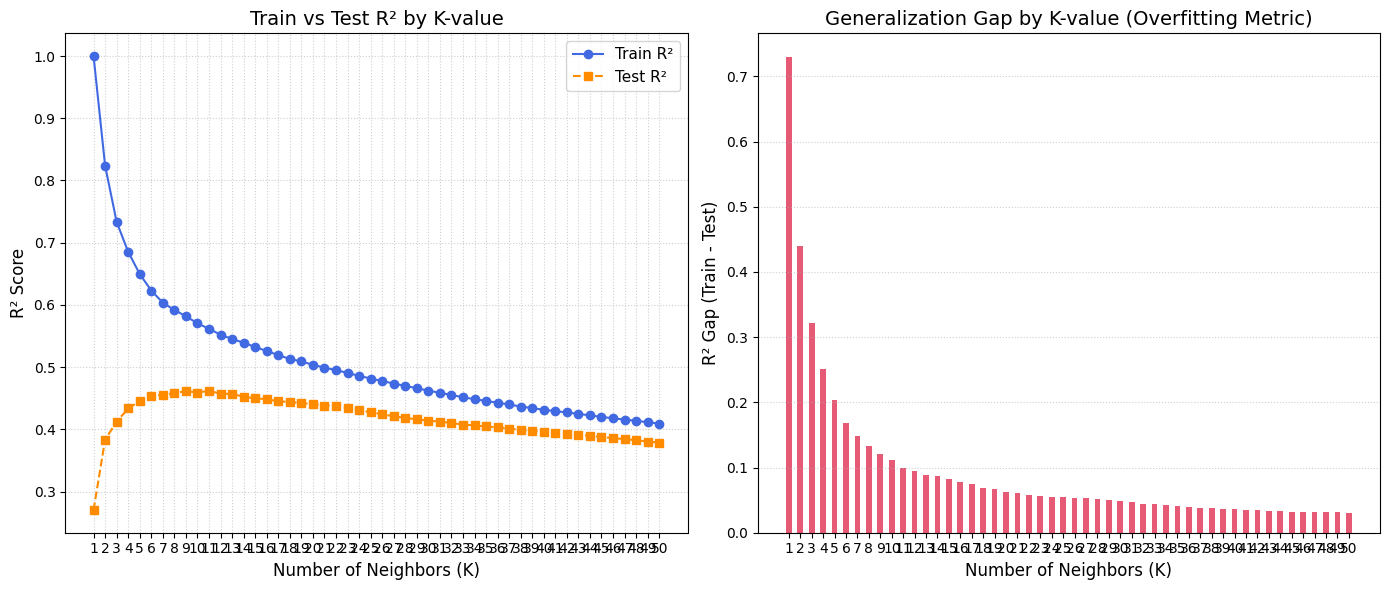

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures # PolynomialFeatures 임포트 추가
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

# 1. 피처 및 타겟 지정 (데이터프레임 df가 사전에 정의되어 있다고 가정합니다)
df.columns = df.columns.str.strip()
input_cols = [f"Current_J{i}" for i in range(6)] + [f"Speed_J{i}" for i in range(6)]
target_col = "Tool_current"

clean_df = df.dropna(subset=input_cols + [target_col])
X = clean_df[input_cols]
y = clean_df[target_col]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 시각화를 위해 결과를 저장할 리스트 정의
k_values = []
train_results = []
test_results = []
gap_results = []

for i in range(1,50+1):
  k_values.append(i)

print("--- [KNN 평가 루프 시작] ---")
for K in k_values:
    knn = KNeighborsRegressor(n_neighbors=K, n_jobs=-1)
    train_r2s = []
    test_r2s = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx].values, y.iloc[test_idx].values

        # 전처리: 스케일링
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # 전처리: 다항 피처 변환
        poly = PolynomialFeatures(degree=2, include_bias=False)
        X_train_poly = poly.fit_transform(X_train_scaled)
        X_test_poly = poly.transform(X_test_scaled)

        # 모델 학습
        knn.fit(X_train_poly, y_train)

        # R2 스코어 기록
        train_r2s.append(r2_score(y_train, knn.predict(X_train_poly)))
        test_r2s.append(r2_score(y_test, knn.predict(X_test_poly)))

    mean_train = np.mean(train_r2s)
    mean_test = np.mean(test_r2s)
    mean_gap = mean_train - mean_test

    # 결과를 리스트에 저장
    train_results.append(mean_train)
    test_results.append(mean_test)
    gap_results.append(mean_gap)

    print(f"KNN (K={K:<2}) -> Train R2: {mean_train:.4f} | Test R2: {mean_test:.4f} | Gap: {mean_gap:.4f}")


# 2. 시각화 (Matplotlib 활용)
plt.figure(figsize=(14, 6))

# 첫 번째 그래프: K값에 따른 Train vs Test R2 성능 비교
plt.subplot(1, 2, 1)
plt.plot(k_values, train_results, marker='o', linestyle='-', color='royalblue', label='Train R²')
plt.plot(k_values, test_results, marker='s', linestyle='--', color='darkorange', label='Test R²')
plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Train vs Test R² by K-value', fontsize=14)
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

# 두 번째 그래프: K값에 따른 일반화 격차 (Train R2 - Test R2) 비교
plt.subplot(1, 2, 2)
plt.bar([str(k) for k in k_values], gap_results, color='crimson', alpha=0.7, width=0.5)
plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('R² Gap (Train - Test)', fontsize=12)
plt.title('Generalization Gap by K-value (Overfitting Metric)', fontsize=14)
plt.grid(True, axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

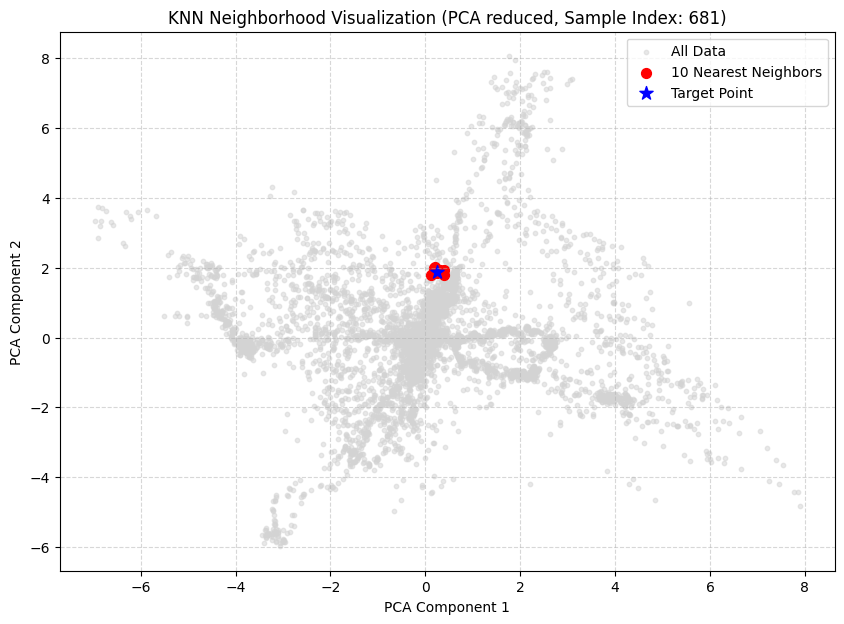

In [34]:
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

# 1. 시각화를 위해 전체 데이터를 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. PCA를 이용한 2차원 축소
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. 특정 포인트의 이웃 찾기 (예: K=10일 때)
K_val = 10
nbrs = NearestNeighbors(n_neighbors=K_val).fit(X_pca)
distances, indices = nbrs.kneighbors(X_pca)

# 4. 시각화
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='lightgrey', alpha=0.5, label='All Data', s=10)

# 랜덤하게 하나의 샘플 포인트 선택하여 그 이웃들을 강조
sample_idx = np.random.randint(len(X_pca))
neighbors_idx = indices[sample_idx]

plt.scatter(X_pca[neighbors_idx, 0], X_pca[neighbors_idx, 1], c='red', s=50, label=f'{K_val} Nearest Neighbors')
plt.scatter(X_pca[sample_idx, 0], X_pca[sample_idx, 1], c='blue', s=100, marker='*', label='Target Point')

plt.title(f'KNN Neighborhood Visualization (PCA reduced, Sample Index: {sample_idx})')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline

# 1. 데이터 준비 (기존 코드와 동일)
df.columns = df.columns.str.strip()
input_cols = [f"Current_J{i}" for i in range(6)] + [f"Speed_J{i}" for i in range(6)]
target_col = "Tool_current"

clean_df = df.dropna(subset=input_cols + [target_col])
X = clean_df[input_cols]
y = clean_df[target_col]

# 2. 파이프라인(Pipeline) 구축
# 전처리와 모델을 순서대로 정의합니다.
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('knn', KNeighborsRegressor()) # 병렬 처리(n_jobs=-1)는 GridSearchCV에서 수행하므로 여기서는 뺍니다.
])

# 3. 탐색할 하이퍼파라미터 그리드 정의
# 주의: Pipeline 안의 파라미터를 지정할 때는 '단계이름__파라미터명' 형식을 사용합니다. (언더바 2개)
param_grid = {
    'knn__n_neighbors': list(range(1, 50 + 1)),       # K 값 1~50
    'knn__weights': ['uniform', 'distance'],          # 가중치 방식
    'knn__metric': ['euclidean', 'manhattan']         # 거리 측정 방식
}

# 4. KFold 및 GridSearchCV 설정
kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=kf,
    scoring='r2',
    return_train_score=True,  # Train R2 점수도 반환하여 과적합 확인
    n_jobs=-1,                # 모든 CPU 코어 사용 (빠른 연산)
    verbose=1                 # 진행 상황 간략히 출력
)

print(f"--- Grid Search 시작 ---")
print(f"총 탐색 조합 수: 50(K) x 2(Weights) x 2(Metric) = 200개 모델")
print(f"(5-Fold CV이므로 총 1,000번의 학습이 진행됩니다. 잠시만 기다려주세요...)")

# 5. Grid Search 실행 (학습)
grid_search.fit(X, y)

# 6. 결과 정리 및 DataFrame 변환
results_df = pd.DataFrame(grid_search.cv_results_)

# 보기 쉽게 필요한 컬럼만 추출하고 이름 변경
cols_to_keep = [
    'param_knn__n_neighbors', 'param_knn__weights', 'param_knn__metric',
    'mean_train_score', 'mean_test_score', 'rank_test_score'
]
final_results = results_df[cols_to_keep].copy()
final_results.rename(columns={
    'param_knn__n_neighbors': 'K',
    'param_knn__weights': 'Weights',
    'param_knn__metric': 'Metric',
    'mean_train_score': 'Train R2',
    'mean_test_score': 'Test R2',
    'rank_test_score': 'Rank'
}, inplace=True)

# 일반화 격차(Gap) 계산 추가
final_results['Gap (Train-Test)'] = final_results['Train R2'] - final_results['Test R2']

# 7. Test R2 점수를 기준으로 1등부터 순서대로 정렬
final_results = final_results.sort_values(by='Rank')

print("\n--- [Grid Search 최적 모델 결과] ---")
print(f"최고 성능 파라미터: {grid_search.best_params_}")
print(f"최고 Test R2 점수: {grid_search.best_score_:.4f}\n")

print("--- [전체 조합 성능 순위 (상위 20개)] ---")
# 소수점 4자리까지만 표시되도록 스타일 설정 후 출력
display(final_results.head(20).style.format({
    'Train R2': '{:.4f}',
    'Test R2': '{:.4f}',
    'Gap (Train-Test)': '{:.4f}'
}))

--- Grid Search 시작 ---
총 탐색 조합 수: 50(K) x 2(Weights) x 2(Metric) = 200개 모델
(5-Fold CV이므로 총 1,000번의 학습이 진행됩니다. 잠시만 기다려주세요...)
Fitting 5 folds for each of 200 candidates, totalling 1000 fits


KeyboardInterrupt: 